In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
csv_path  = "M2_2.18mM_37deg_pressure_o2_release.csv"
time_col  = "Time (s)"                     # your column is actually hours
press_col = "DWT denoised pressure (kPa)"  # pressure in kPa
gas_col   = "O2 Released (µmol)"          # headspace O2 from csv

In [2]:
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# Temperature range according to time

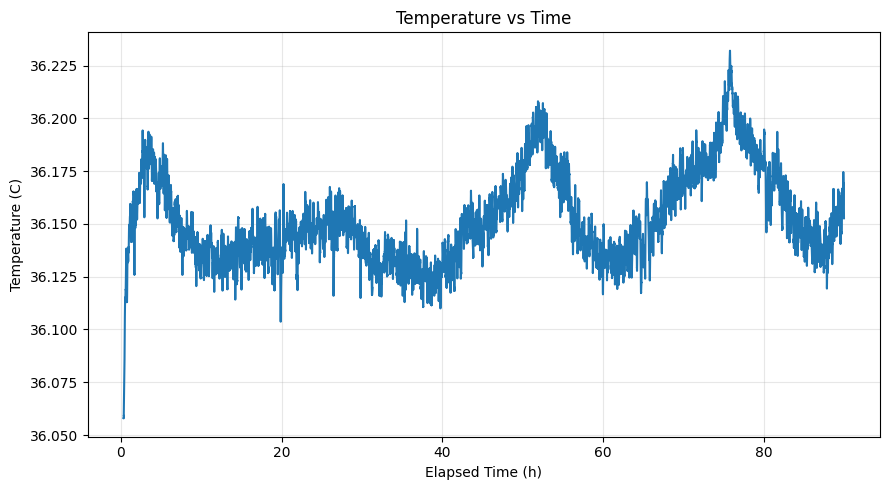

In [68]:
main_csv = r"M2_2.18mM_37deg_pressure_o2_release.csv"   # has Time, Pressure, Temp
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
temperature_col = "calibrated temperature (C)"
time_col = "Time (s)"

t_h = pd.to_numeric(df_main[time_col], errors="coerce")
plt.figure(figsize=(9,5))
plt.plot(t_h, df_main[temperature_col], label="Temperature (C)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Temperature (C)")
plt.title("Temperature vs Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# First things first, fixing the temperature - enthalpy - henry constants


In [8]:
import pandas as pd
from pathlib import Path
import numpy as np

# ====== user inputs ======
csv_path  = "M2_2.18mM_37deg_pressure_o2_release.csv"  
temp_col  = "calibrated temperature (C)"   # <-- exact column name in your file
# =========================

# Eq. (11) coefficients for O2 in water (<348 K)
A1 = 83.91236
A2 = 23.24323
R = 8.314462618  # J·mol^-1·K^-1

def deltaH_J_per_mol(T_K: pd.Series) -> pd.Series:
    """
    ΔH°(T) = R * (A2*T - 100*A1)  [J/mol]
    (Since A3 = A4 = 0 for this temperature range.)
    """
    return R * (A2 * T_K - 100.0 * A1)

# --- load & clean ---
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]
T_C_orig = pd.to_numeric(df[temp_col], errors="coerce").dropna().reset_index(drop=True)

# --- round °C to 2 decimals, convert to K ---
T_C_round2 = T_C_orig.round(2)
T_K_from_round = T_C_round2 + 273.15

# --- compute ΔH ---
dH_Jmol  = deltaH_J_per_mol(T_K_from_round)
dH_kJmol = dH_Jmol / 1000.0

# --- assemble output table ---
out = pd.DataFrame({
    "T_C_original": T_C_orig,
    "T_C_rounded_2dp": T_C_round2,
    "T_K_from_rounded": T_K_from_round,
    "DeltaH_kJ_per_mol": dH_kJmol
})

# --- save ---
out_path = Path(csv_path).with_name(Path(csv_path).stem + "37deg_DeltaH_from_T.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out.head(8).to_string(index=False))

Saved: M2_2.18mM_37deg_pressure_o2_release37deg_DeltaH_from_T.csv
 T_C_original  T_C_rounded_2dp  T_K_from_rounded  DeltaH_kJ_per_mol
    36.057967            36.06            309.21          -10.01225
    36.057966            36.06            309.21          -10.01225
    36.057900            36.06            309.21          -10.01225
    36.057900            36.06            309.21          -10.01225
    36.057967            36.06            309.21          -10.01225
    36.057933            36.06            309.21          -10.01225
    36.057950            36.06            309.21          -10.01225
    36.058017            36.06            309.21          -10.01225


In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

# ===== inputs =====
# CSV produced in the previous step (with T_K_from_rounded + DeltaH_kJ_per_mol)
dh_csv_path = "M2_2.18mM_37deg_pressure_o2_release37deg_DeltaH_from_T.csv"
tempK_col   = "T_K_from_rounded"      # Kelvin (from rounded °C)
dH_col      = "DeltaH_kJ_per_mol"     # kJ/mol
tempC_col   = "T_C_original"    # optional; for reference only



T_REF_K     = 298.15                  # K
kH_ref_atm  = 1.30e-3                 # mol·L^-1·atm^-1 at 297.15 K
R_J         = 8.314462618             # J·mol^-1·K^-1
# ==================

# Load ΔH data
df = pd.read_csv(dh_csv_path)
TK = pd.to_numeric(df[tempK_col], errors="coerce")
dH_kJmol = pd.to_numeric(df[dH_col], errors="coerce")
tempC = pd.to_numeric(df.get(tempC_col, pd.Series([])), errors="coerce")

# van’t Hoff: kH(T) = kH_ref * exp( -(ΔH/R)*(1/T - 1/T_ref) )
dH_Jmol = dH_kJmol * 1000.0
ln_ratio = -dH_Jmol / R_J * (1.0/TK - 1.0/T_REF_K)
kH_T_atm = kH_ref_atm * np.exp(ln_ratio)   # mol·L^-1·atm^-1

# Build output table
out = pd.DataFrame({
    "Temperature_K": TK,
    "DeltaH_kJ_per_mol": dH_kJmol,
    "kH_mol_per_L_atm": kH_T_atm,
    "calibrated temperature (C)" : tempC
})

# Save
out_path = Path("henrys_constants_37deg.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out.head().to_string(index=False))



Saved: henrys_constants_37deg.csv
 Temperature_K  DeltaH_kJ_per_mol  kH_mol_per_L_atm  calibrated temperature (C)
        309.21          -10.01225          0.001125                   36.057967
        309.21          -10.01225          0.001125                   36.057966
        309.21          -10.01225          0.001125                   36.057900
        309.21          -10.01225          0.001125                   36.057900
        309.21          -10.01225          0.001125                   36.057967


# Behaviour profile of KH with respect to time and temperature.

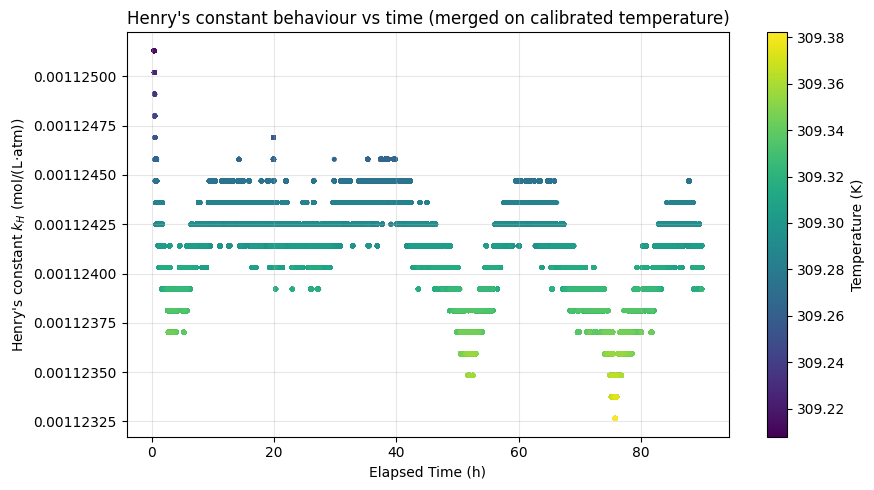

In [ ]:

# Behaviour profile of KH with respect to time and temperature (37 deg C data)



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- paths ---
main_csv_path  = r"M2_2.18mM_37deg_pressure_o2_release.csv"   # has Time (s), DWT..., calibrated temperature (C)
henry_csv_path = r"henrys_constants_37deg.csv"                # has kH_mol_per_L_atm, calibrated temperature (C) (and/or Temperature_K)

time_col   = "Time (s)"
press_col  = "DWT denoised pressure (kPa)"
tempC_col  = "calibrated temperature (C)"
kH_col     = "kH_mol_per_L_atm"
T_K_col   = "Temperature_K"  

# --- load & clean ---
df_main  = pd.read_csv(main_csv_path)
df_henry = pd.read_csv(henry_csv_path)
df_main.columns  = [c.strip() for c in df_main.columns]
df_henry.columns = [c.strip() for c in df_henry.columns]

# keep only the columns we need
df_main  = df_main[[time_col, tempC_col]].copy()
df_henry = df_henry[[tempC_col, kH_col]].copy()

# ensure numeric
df_main[time_col]  = pd.to_numeric(df_main[time_col], errors="coerce")
df_main[tempC_col] = pd.to_numeric(df_main[tempC_col], errors="coerce")
df_henry[tempC_col]= pd.to_numeric(df_henry[tempC_col], errors="coerce")
df_henry[kH_col]   = pd.to_numeric(df_henry[kH_col],   errors="coerce")

# sort for asof-merge and merge on temperature (nearest within ±0.1 °C)
dfm = pd.merge_asof(
    df_main.sort_values(tempC_col),
    df_henry.sort_values(tempC_col),
    on=tempC_col,
    tolerance=0.1,      # adjust tolerance if needed
    direction="nearest" # nearest temperature match
).sort_index()

# time in hours
t_h = dfm[time_col]
k_h = dfm[kH_col]
T_K = dfm[tempC_col] + 273.15

# --- plot kH vs time, coloured by temperature ---
plt.figure(figsize=(9,5))
sc = plt.scatter(t_h, k_h, c=T_K, cmap="viridis", s=12, edgecolors="none")
cbar = plt.colorbar(sc)
cbar.set_label("Temperature (K)")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Henry's constant $k_H$ (mol/(L·atm))")
plt.title("Henry's constant behaviour vs time (merged on calibrated temperature)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


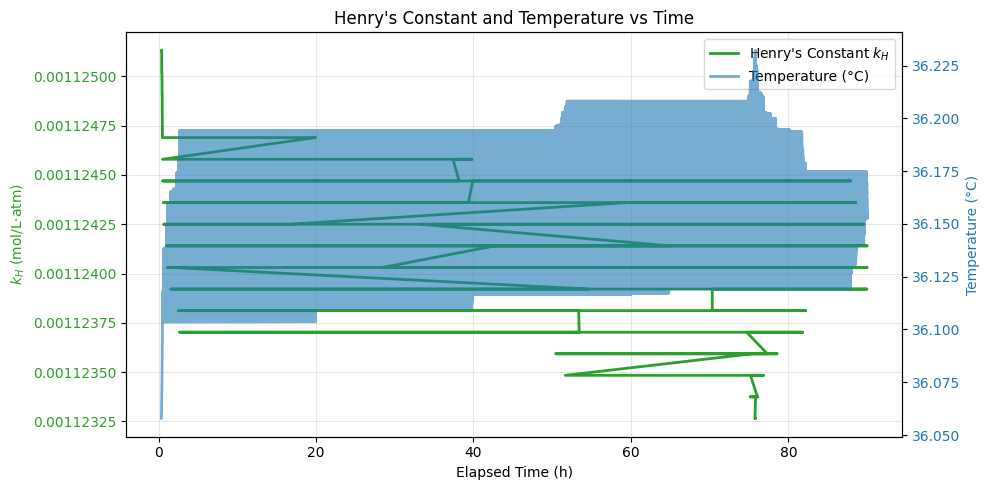

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- paths ---
main_csv_path  = r"M2_2.18mM_37deg_pressure_o2_release.csv"
henry_csv_path = r"henrys_constants_37deg.csv"

# --- columns ---
time_col   = "Time (s)"
tempC_col  = "calibrated temperature (C)"
kH_col     = "kH_mol_per_L_atm"

# --- load & clean ---
df_main  = pd.read_csv(main_csv_path)
df_henry = pd.read_csv(henry_csv_path)
df_main.columns  = [c.strip() for c in df_main.columns]
df_henry.columns = [c.strip() for c in df_henry.columns]

# Keep relevant columns only
df_main  = df_main[[time_col, tempC_col]].copy()
df_henry = df_henry[[tempC_col, kH_col]].copy()

# Convert to numeric
df_main[time_col]  = pd.to_numeric(df_main[time_col], errors="coerce")
df_main[tempC_col] = pd.to_numeric(df_main[tempC_col], errors="coerce")
df_henry[tempC_col]= pd.to_numeric(df_henry[tempC_col], errors="coerce")
df_henry[kH_col]   = pd.to_numeric(df_henry[kH_col],   errors="coerce")

# Merge on temperature using nearest match
dfm = pd.merge_asof(
    df_main.sort_values(tempC_col),
    df_henry.sort_values(tempC_col),
    on=tempC_col,
    tolerance=0.1,
    direction="nearest"
).sort_index()

# Convert time to hours
t_h = dfm[time_col] 
k_h = dfm[kH_col]
temp_C = dfm[tempC_col]

# --- plot with twin y-axes ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot kH on left y-axis
ax1.plot(t_h, k_h, color="tab:green", label="Henry's Constant $k_H$", linewidth=2)
ax1.set_ylabel("$k_H$ (mol/L·atm)", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")

# Twin y-axis for temperature
ax2 = ax1.twinx()
ax2.plot(t_h, temp_C, color="tab:blue", label="Temperature (°C)", linewidth=2, alpha=0.6)
ax2.set_ylabel("Temperature (°C)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Common x-label and title
ax1.set_xlabel("Elapsed Time (h)")
plt.title("Henry's Constant and Temperature vs Time")
ax1.grid(True, alpha=0.3)

# Legend handling
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()



$k_H$ is inversely related to temperature: when T rises slightly, $k_H$ decreases, and vice versa.

# Behaviour profile of KH in 37 deg vs RT comparison

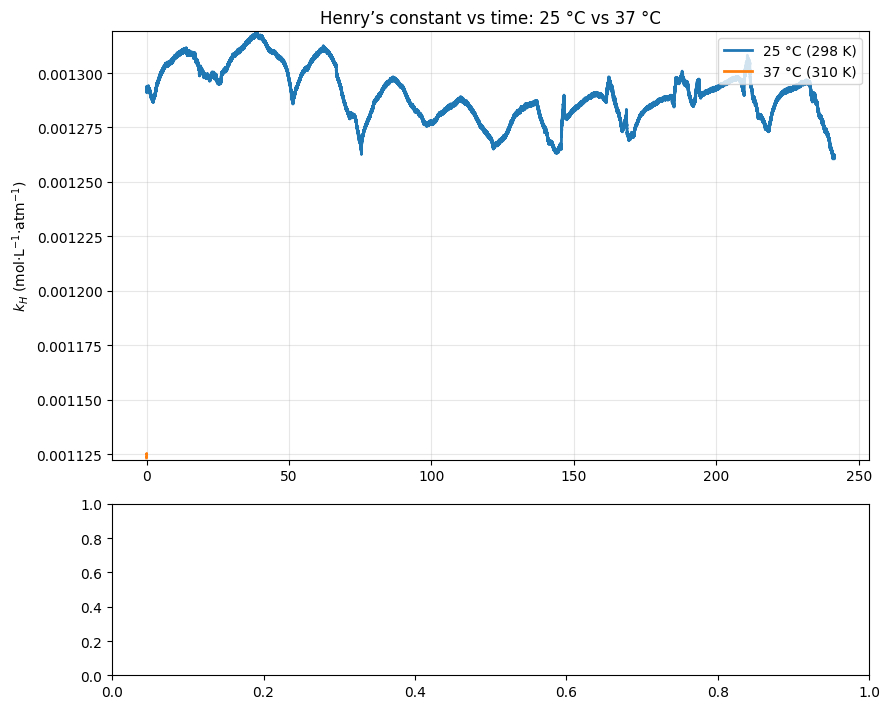

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------ FILES & COLUMNS ------------------
rt_csv   = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\ntot from vanthoff fit.csv"
rt_time  = "Elapsed Time (h)"
rt_kH    = "kH_mol_per_L_atm"

t37_main = r"M2_2.18mM_37deg_pressure_o2_release.csv"
t37_kh   = r"henrys_constants_37deg.csv"
m_time_s = "Time (s)"
m_tempC  = "calibrated temperature (C)"
h_tempC  = "calibrated temperature (C)"
h_kH     = "kH_mol_per_L_atm"

# ------------------ LOAD 25 °C ------------------
df_rt = pd.read_csv(rt_csv)
df_rt.columns = [c.strip() for c in df_rt.columns]
t_rt  = pd.to_numeric(df_rt[rt_time], errors="coerce")
kH_rt = pd.to_numeric(df_rt[rt_kH],  errors="coerce")
mask  = t_rt.notna() & kH_rt.notna()
t_rt, kH_rt = t_rt[mask].reset_index(drop=True), kH_rt[mask].reset_index(drop=True)

# ------------------ LOAD 37 °C (merge on temperature) ------------------
df_m  = pd.read_csv(t37_main);  df_m.columns  = [c.strip() for c in df_m.columns]
df_h  = pd.read_csv(t37_kh);    df_h.columns  = [c.strip() for c in df_h.columns]

df_m = df_m[[m_time_s, m_tempC]].copy()
df_h = df_h[[h_tempC, h_kH]].copy()

df_m[m_time_s]  = pd.to_numeric(df_m[m_time_s],  errors="coerce")
df_m[m_tempC]   = pd.to_numeric(df_m[m_tempC],   errors="coerce")
df_h[h_tempC]   = pd.to_numeric(df_h[h_tempC],   errors="coerce")
df_h[h_kH]      = pd.to_numeric(df_h[h_kH],      errors="coerce")

df37 = pd.merge_asof(
    df_m.sort_values(m_tempC),
    df_h.sort_values(h_tempC),
    left_on=m_tempC, right_on=h_tempC,
    tolerance=0.1, direction="nearest"
).sort_index().dropna(subset=[m_time_s, h_kH])

t_37  = df37[m_time_s] / 3600.0   # seconds -> hours
kH_37 = df37[h_kH]

# ------------------ SHARED Y LIMITS ------------------
ymin = np.nanmin([kH_rt.min(), kH_37.min()])
ymax = np.nanmax([kH_rt.max(), kH_37.max()])
pad  = 0.0000008
ylims = (ymin - pad, ymax + pad)

# ------------------ PLOT ------------------
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 7.2), gridspec_kw={"height_ratios":[2.5,1]}, sharex=False)

# (A) Overlay kH vs time
ax_top.plot(t_rt,  kH_rt,  lw=2, label="25 °C (298 K)")
ax_top.plot(t_37,  kH_37,  lw=2, label="37 °C (310 K)")
ax_top.set_ylabel(r"$k_H$ (mol·L$^{-1}$·atm$^{-1}$)")
ax_top.set_title("Henry’s constant vs time: 25 °C vs 37 °C")
ax_top.grid(True, alpha=0.3)
ax_top.set_ylim(*ylims)
ax_top.legend(loc="upper right")


plt.tight_layout()
plt.show()


# Pressure in atm

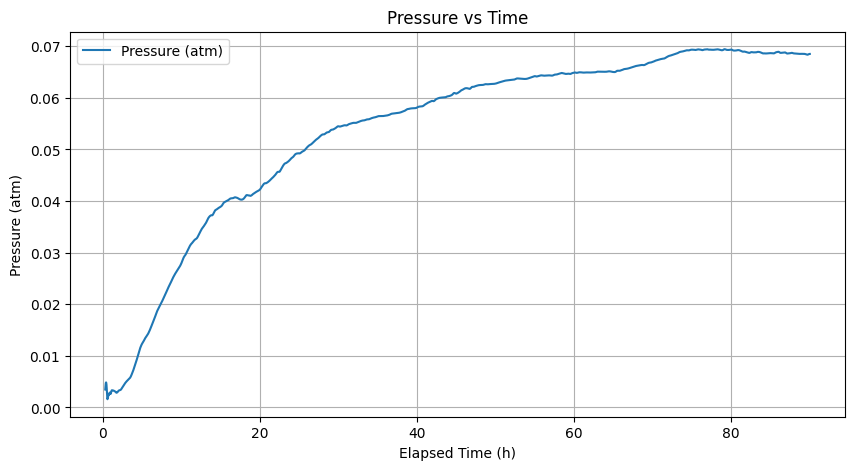

0.06943199624906128


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



main_csv = r"M2_2.18mM_37deg_pressure_o2_release.csv"   # has Time, Pressure, Temp
kh_csv   = r"henrys_constants_37deg.csv"                # has Temperature_K, kH_mol_per_L_atm
df_main = pd.read_csv(main_csv)
df_kh   = pd.read_csv(kh_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh.columns   = [c.strip() for c in df_kh.columns]

pressure_col = df_main["DWT denoised pressure (kPa)"] / 101.325  # convert kPa to atm
time_col = df_main["Time (s)"] 

plt.figure(figsize=(10, 5))
plt.plot(time_col, pressure_col, label="Pressure (atm)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Pressure (atm)")
plt.title("Pressure vs Time")
plt.legend()
plt.grid()
plt.show()

print(max(pressure_col))

# nheadspace detected by sensor

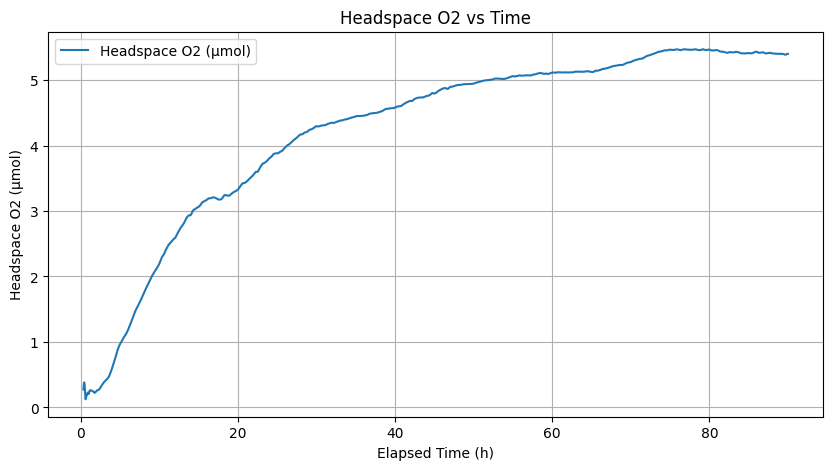

5.470722696968963


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



main_csv = r"M2_2.18mM_37deg_pressure_o2_release.csv"   # has Time, Pressure, Temp
kh_csv   = r"henrys_constants_37deg.csv"                # has Temperature_K, kH_mol_per_L_atm
df_main = pd.read_csv(main_csv)
df_kh   = pd.read_csv(kh_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh.columns   = [c.strip() for c in df_kh.columns]

headspace_oxygen = df_main["O2 Released (µmol)"]
time_col = df_main["Time (s)"] 

plt.figure(figsize=(10, 5))
plt.plot(time_col, headspace_oxygen, label="Headspace O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Headspace O2 (µmol)")
plt.title("Headspace O2 vs Time")
plt.legend()
plt.grid()
plt.show()

print(max(headspace_oxygen))

The very last value (detected by sensor) :                 5.39933560851716 


The max value detected by the sensor in headspace :        5.470722696968963

# naq in atm

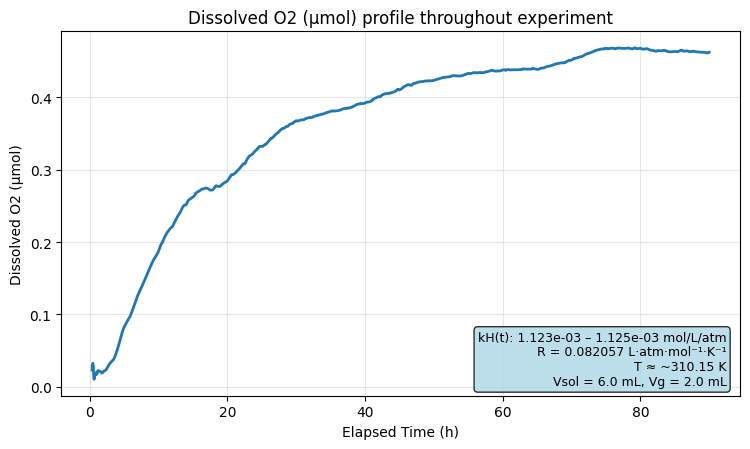

0.4681648939062673
0.4621483342808676


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_37deg_pressure_o2_release.csv"       
kh_csv     = r"henrys_constants_37deg.csv"   # columns: Temperature_K, DeltaH_kJ_per_mol, kH_mol_per_L_atm, calibrated temperature (C)
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
T = 310.15              # K (37 °C) – used only for the info box
Vsol = 0.006            # L
Vg   = 0.002            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm


n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_kpa (kPa)": p_kpa,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_aq (µmol)": n_aq_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_aq (µmol)"], linewidth=2)
plt.ylabel("Dissolved O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Dissolved O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~{T:.2f} K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(max(n_aq_umol))
print(n_aq_umol.iloc[-1])





The very last value                               :                0.4681648939062673

The max value                                      :               0.4621483342808676

# Total oxygen released 
ntot = naq + ndissolved


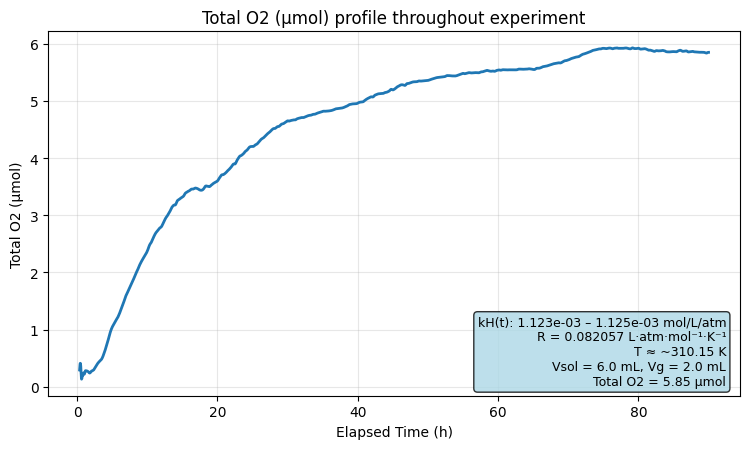

5.924475366998874
5.846733477626991


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_37deg_pressure_o2_release.csv"       
kh_csv     = r"henrys_constants_37deg.csv"   # columns: Temperature_K, DeltaH_kJ_per_mol, kH_mol_per_L_atm, calibrated temperature (C)
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
T = 310.15              # K (37 °C) – used only for the info box
Vsol = 0.006            # L
Vg   = 0.002            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm




def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T, kH_time)



# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~{T:.2f} K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Total O2 = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(max(ntot_umol))
print(ntot_umol.iloc[-1])


Total O2 that is available:
Max value reached  :  5.924475366998874




Last value reached : 5.846733477626991

# Comparison of ntotal plot with theoretical max 13.08

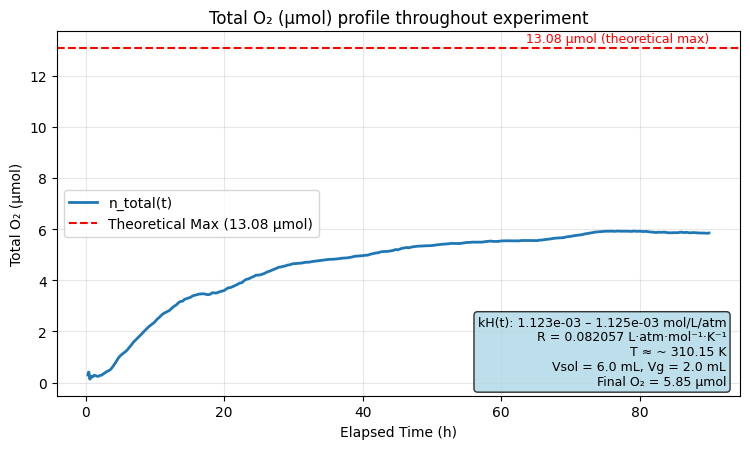

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_37deg_pressure_o2_release.csv"       
kh_csv     = r"henrys_constants_37deg.csv"   # columns: Temperature_K, DeltaH_kJ_per_mol, kH_mol_per_L_atm, calibrated temperature (C)
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
T = 310.15              # K (37 °C)
Vsol = 0.006            # L
Vg   = 0.002            # L
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

# ---------- calculate n_total ----------
def calculate_n_total(p_atm, Vg, Vsol, R, T, KH):
    ntot = p_atm * ((Vg / (R*T)) + (KH * Vsol))
    return ntot * 1e6  # µmol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T, kH_time)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total (µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total (µmol)"], linewidth=2, label="n_total(t)")
plt.axhline(y=n_theory, color="red", linestyle="--", linewidth=1.5, label="Theoretical Max (13.08 µmol)")

# Put label near the top-right corner
plt.text(df_out["Elapsed Time (h)"].max(), n_theory+0.1,
         f"{n_theory} µmol (theoretical max)", color="red",
         ha="right", va="bottom", fontsize=9)

plt.ylabel("Total O₂ (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O₂ (µmol) profile throughout experiment")
plt.legend()

# Info box
kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ {T:.2f} K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Final O₂ = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Comparison of naq and ndissolved plots

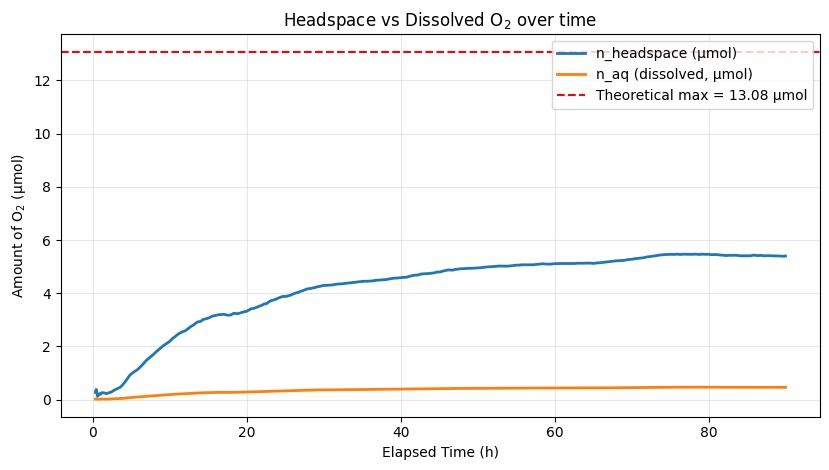

In [34]:
# --- continue from your variables above ---

# Convert time to hours (if it's in seconds)
time_h = pd.to_numeric(df[time_col], errors="coerce") 
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
p_atm  = p_kpa / 101.325
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
n_headspace = pd.to_numeric(df["O2 Released (µmol)"], errors="coerce")

# Dissolved O2 from Henry’s law (µmol)
n_aq_umol = (kH_time * Vsol * p_atm) * 1e6

# Align lengths safely
n = min(len(time_h), len(p_atm), len(kH_time), len(n_headspace), len(n_aq_umol))
time_h       = time_h.iloc[:n].reset_index(drop=True)
p_atm        = p_atm.iloc[:n].reset_index(drop=True)
kH_time      = kH_time.iloc[:n].reset_index(drop=True)
n_headspace  = n_headspace.iloc[:n].reset_index(drop=True)
n_aq_umol    = n_aq_umol.iloc[:n].reset_index(drop=True)

# Optional total
n_total_umol = n_headspace + n_aq_umol

# ---- Plot both on one figure ----
plt.figure(figsize=(8.4, 4.8))
plt.plot(time_h, n_headspace, lw=2, label="n_headspace (µmol)")
plt.plot(time_h, n_aq_umol, lw=2, label="n_aq (dissolved, µmol)")
plt.axhline(n_theory, ls="--", c="red", lw=1.5, label=f"Theoretical max = {n_theory} µmol")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Amount of O$_2$ (µmol)")
plt.title("Headspace vs Dissolved O$_2$ over time")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_headspace (µmol)": n_headspace,
    "n_aq (µmol)": n_aq_umol,
    "n_total (µmol)": n_total_umol
})




# Comparison of naq, ndissolved and ntotal plot

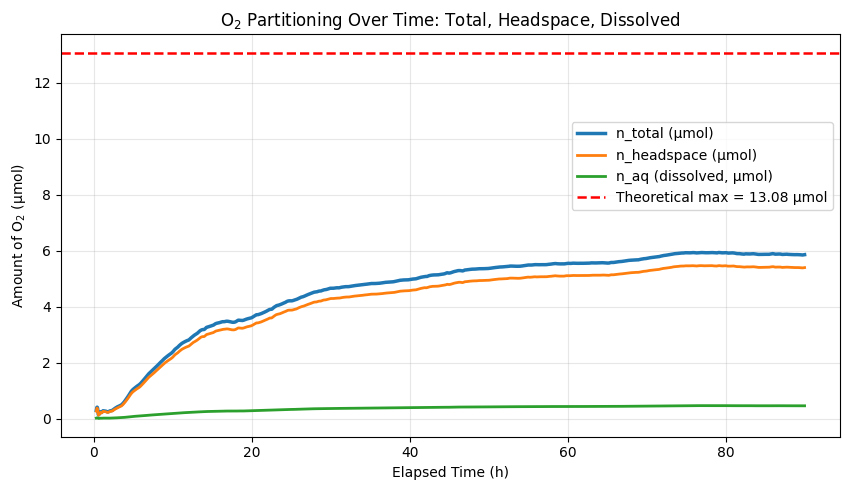

In [52]:

time_h       = pd.to_numeric(df[time_col], errors="coerce") 
p_kpa        = pd.to_numeric(df[press_col], errors="coerce")
p_atm        = p_kpa / 101.325
kH_time      = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
n_headspace  = pd.to_numeric(df["O2 Released (µmol)"], errors="coerce")

# Dissolved O2 (µmol)
n_aq_umol = (kH_time * Vsol * p_atm) * 1e6

# Align lengths
n = min(len(time_h), len(p_atm), len(kH_time), len(n_headspace), len(n_aq_umol))
time_h       = time_h.iloc[:n].reset_index(drop=True)
p_atm        = p_atm.iloc[:n].reset_index(drop=True)
kH_time      = kH_time.iloc[:n].reset_index(drop=True)
n_headspace  = n_headspace.iloc[:n].reset_index(drop=True)
n_aq_umol    = n_aq_umol.iloc[:n].reset_index(drop=True)

# Totals
n_total_umol = n_headspace + n_aq_umol

# ---- Plot all four ----
plt.figure(figsize=(8.6, 5.0))
plt.plot(time_h, n_total_umol,   lw=2.5, label="n_total (µmol)")
plt.plot(time_h, n_headspace,    lw=2.0, label="n_headspace (µmol)")
plt.plot(time_h, n_aq_umol,      lw=2.0, label="n_aq (dissolved, µmol)")
plt.axhline(n_theory, ls="--", lw=1.8, color="red", label=f"Theoretical max = {n_theory} µmol")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Amount of O$_2$ (µmol)")
plt.title("O$_2$ Partitioning Over Time: Total, Headspace, Dissolved")
plt.grid(True, alpha=0.3)

# Move legend to top-right corner, outside the plot
plt.legend(loc="upper right", bbox_to_anchor=(1,0.8), frameon=True)

plt.tight_layout()
plt.show()


# (Optional) tidy table for export/inspection
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_headspace (µmol)": n_headspace,
    "n_aq (µmol)": n_aq_umol,
    "n_total (µmol)": n_total_umol
})


# Comparison of ntotal of 37 deg, RT and 13.08 theoretical max

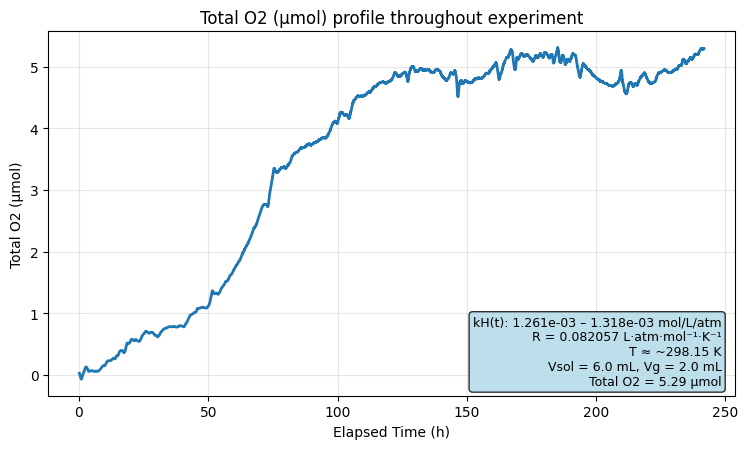

5.304597679048725
5.286482603587783


In [ ]:
# for Room temperature or 25 deg celsius or 298.15 K
main_RT_csv = r"M2_2.18mM_pressure_o2_release.csv"
henry_csv  = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"

# # ---------- inputs ----------
# main_csv   = r"M2_2.18mM_37deg_pressure_o2_release.csv"       
# kh_csv     = r"henrys_constants_37deg.csv"   # columns: Temperature_K, DeltaH_kJ_per_mol, kH_mol_per_L_atm, calibrated temperature (C)
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
T = 298.15              # K (25 °C) – used only for the info box
Vsol = 0.006            # L
Vg   = 0.002            # L

# ---------- load ----------
df = pd.read_csv(main_RT_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(henry_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm


def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T, kH_time)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~{T:.2f} K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Total O2 = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



#for 37 deg celsius or 310.15 K


# ---------- inputs ----------
main_csv   = r"M2_2.18mM_37deg_pressure_o2_release.csv"       
kh_csv     = r"henrys_constants_37deg.csv"   # columns: Temperature_K, DeltaH_kJ_per_mol, kH_mol_per_L_atm, calibrated temperature (C)
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
T = 310.15              # K (37 °C) – used only for the info box
Vsol = 0.006            # L
Vg   = 0.002            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm




def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T, kH_time)



# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~{T:.2f} K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Total O2 = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


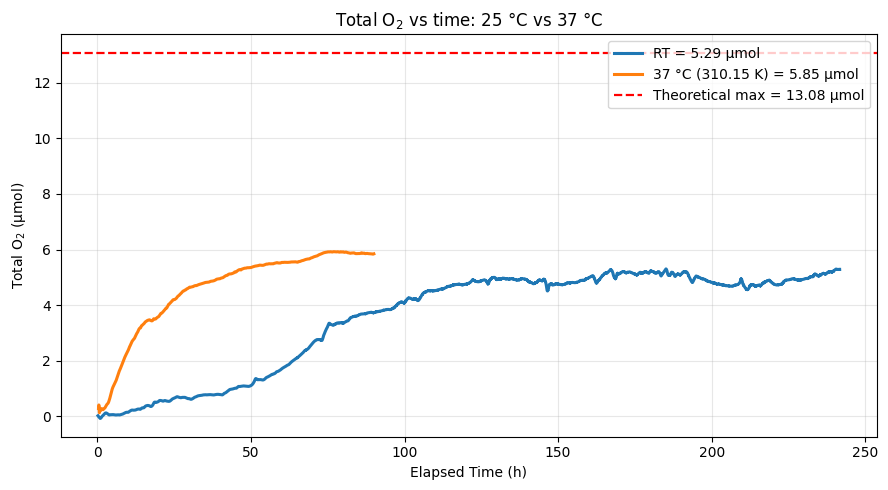

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- file paths ---
main_RT_csv = r"M2_2.18mM_pressure_o2_release.csv"          # 25 °C
henry_RT_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"

main_37_csv = r"M2_2.18mM_37deg_pressure_o2_release.csv"    # 37 °C
henry_37_csv = r"henrys_constants_37deg.csv"

# --- column names (common) ---
time_col  = "Time (s)"
press_col = "DWT denoised pressure (kPa)"

# --- constants ---
R    = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006               # L
Vg   = 0.002               # L
T_RT = 298.15              # K (25 °C)
T_37 = 310.15              # K (37 °C)
n_theory = 13.08           # µmol (optional reference line)

def compute_ntotal_series(main_csv, kh_csv, T_K, label):
    """Return a tidy df with time_h and n_total (µmol) for a dataset."""
    df = pd.read_csv(main_csv)
    df.columns = [c.strip() for c in df.columns]
    df_kh = pd.read_csv(kh_csv)
    df_kh.columns = [c.strip() for c in df_kh.columns]

    time_h = pd.to_numeric(df[time_col], errors="coerce") 
    p_kPa  = pd.to_numeric(df[press_col], errors="coerce")
    p_atm  = p_kPa / 101.325

    kH_series = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
    # Broadcast single value or align by index length
    if kH_series.size == 1:
        kH_time = np.full(len(time_h), float(kH_series.iloc[0]))
    else:
        n = min(len(time_h), len(kH_series), len(p_atm))
        time_h = time_h.iloc[:n].reset_index(drop=True)
        p_atm  = p_atm.iloc[:n].reset_index(drop=True)
        kH_time = kH_series.iloc[:n].reset_index(drop=True).to_numpy()

    # n_total(t) = P_abs * (Vg/(R*T) + kH*Vsol)  [mol] → µmol
    A_total = (Vg / (R * T_K)) + (kH_time * Vsol)
    n_total_umol = (p_atm * A_total) * 1e6

    return pd.DataFrame({
        "Elapsed Time (h)": time_h,
        "n_total (µmol)": n_total_umol,
        "label": label
    })

# --- compute both series ---
df_rt  = compute_ntotal_series(main_RT_csv, henry_RT_csv, T_RT,  label="RT = 5.29 µmol")
df_37  = compute_ntotal_series(main_37_csv, henry_37_csv, T_37,  label="37 °C (310.15 K) = 5.85 µmol")

# --- plot together ---
plt.figure(figsize=(9, 5))
plt.plot(df_rt["Elapsed Time (h)"], df_rt["n_total (µmol)"],  lw=2.2, label=df_rt["label"].iloc[0])
plt.plot(df_37["Elapsed Time (h)"], df_37["n_total (µmol)"], lw=2.2, label=df_37["label"].iloc[0])

# optional theoretical max line
plt.axhline(n_theory, ls="--", lw=1.6, color="red", label=f"Theoretical max = {n_theory} µmol")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Total O$_2$ (µmol)")
plt.title("Total O$_2$ vs time: 25 °C vs 37 °C")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# Pressure predictor with streamlit for 37 degrees

#  Comparison of pressure predicted with streamlit for 37 deg vs RT through graphs

# Correlation between pressure predicted between 37 deg vs RT 

# Various graph methods to distinctivly represent the difference in pressure predicted between 37 deg vs RT 

# Other correlations between both of the experiments now that all of the data is available.

make a detailed description of how the temperature being stable affected or helped the pressure or oxygen production part